In [10]:
import bioacoustics_model_zoo as bmz
from pathlib import Path
model = bmz.BirdNET()

downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [2]:
import os
from pathlib import Path

# Directory containing the audio files
audio_dir = "/mnt/class_data/Shelby/One_Minute_Audio"

# Find all WAV files with spaces in their names
wav_files = list(Path(audio_dir).glob("*.WAV"))
renamed_count = 0

for wav_file in wav_files:
    if ' ' in wav_file.name:
        # Create new filename by replacing spaces with underscores
        new_name = wav_file.name.replace(' ', '_')
        new_path = wav_file.parent / new_name
        
        # Rename the file
        os.rename(wav_file, new_path)
        renamed_count += 1
        print(f"Renamed: {wav_file.name} -> {new_name}")

print(f"\nTotal files renamed: {renamed_count}")

Renamed: SL43 Trial 1_trim.WAV -> SL43_Trial_1_trim.WAV
Renamed: SL07 Trial 2_trim.WAV -> SL07_Trial_2_trim.WAV
Renamed: SL54 Trial 1_trim.WAV -> SL54_Trial_1_trim.WAV
Renamed: SL02 Trial 1_trim.WAV -> SL02_Trial_1_trim.WAV
Renamed: SL09 Trial 3_trim.WAV -> SL09_Trial_3_trim.WAV
Renamed: RC02 Trial 1_trim.WAV -> RC02_Trial_1_trim.WAV
Renamed: EF04 Trial 3_trim.WAV -> EF04_Trial_3_trim.WAV
Renamed: SL35 Trial 1_trim.WAV -> SL35_Trial_1_trim.WAV
Renamed: SL37 Trial 1_trim.WAV -> SL37_Trial_1_trim.WAV
Renamed: SL50 Trial 1_trim.WAV -> SL50_Trial_1_trim.WAV
Renamed: SL28 Trial 2_trim.WAV -> SL28_Trial_2_trim.WAV
Renamed: SL12 Trial 2_trim.WAV -> SL12_Trial_2_trim.WAV
Renamed: EF01 Trial 2_trim.WAV -> EF01_Trial_2_trim.WAV
Renamed: SL40 Trial 1_trim.WAV -> SL40_Trial_1_trim.WAV
Renamed: SL38 Trial 3_trim.WAV -> SL38_Trial_3_trim.WAV
Renamed: SL30 Trial 1_trim.WAV -> SL30_Trial_1_trim.WAV
Renamed: SL49 Trial 3_trim.WAV -> SL49_Trial_3_trim.WAV
Renamed: SL22 Trial 1_trim.WAV -> SL22_Trial_1_t

In [3]:
import pandas as pd
from opensoundscape import Audio
from pathlib import Path
import os

# Define paths
audio_dir = "/mnt/class_data/Shelby/One_Minute_Audio"
csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/cv4e_calls_channel1_v2.csv"
output_dir = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Read the CSV with annotations
df = pd.read_csv(csv_path)
print(f"Found {len(df)} annotations in CSV")

# Get unique file IDs to process
unique_files = df['file_id'].unique()
print(f"Processing {len(unique_files)} unique audio files")

# Process each annotation
processed_count = 0
for idx, row in df.iterrows():
    file_id = row['file_id']
    begin_time = row['begin_time_s']
    end_time = row['end_time_s']
    call_type = row['call_type']
    
    # Construct the input audio file path (assuming .WAV extension)
    audio_file_path = Path(audio_dir) / f"{file_id}.WAV"
    
    # Check if the audio file exists
    if not audio_file_path.exists():
        print(f"Warning: Audio file not found: {audio_file_path}")
        continue
    
    # Load the full audio file for each trim
    audio = Audio.from_file(audio_file_path)
    
    # Trim the audio according to begin and end times
    trimmed_audio = audio.trim(start_time=begin_time, end_time=end_time)
    
    # Create output filename: file_id_begin_time_end_time_call_type.wav
    output_filename = f"{file_id}_{begin_time}_{end_time}_{call_type}.WAV"
    output_path = os.path.join(output_dir, output_filename)
    
    # Save the trimmed audio
    trimmed_audio.save(output_path)
    
    processed_count += 1
    if processed_count % 100 == 0:
        print(f"Processed {processed_count}/{len(df)} annotations...")

print(f"Completed! Processed {processed_count} audio clips and saved to {output_dir}")

Found 6238 annotations in CSV
Processing 111 unique audio files
Processed 100/6238 annotations...
Processed 200/6238 annotations...
Processed 300/6238 annotations...
Processed 400/6238 annotations...
Processed 500/6238 annotations...
Processed 600/6238 annotations...
Processed 700/6238 annotations...
Processed 800/6238 annotations...
Processed 900/6238 annotations...
Processed 1000/6238 annotations...
Processed 1100/6238 annotations...
Processed 1200/6238 annotations...
Processed 1300/6238 annotations...
Processed 1400/6238 annotations...
Processed 1500/6238 annotations...
Processed 1600/6238 annotations...
Processed 1700/6238 annotations...
Processed 1800/6238 annotations...
Processed 1900/6238 annotations...
Processed 2000/6238 annotations...
Processed 2100/6238 annotations...
Processed 2200/6238 annotations...
Processed 2300/6238 annotations...
Processed 2400/6238 annotations...
Processed 2500/6238 annotations...
Processed 2600/6238 annotations...
Processed 2700/6238 annotations...


In [4]:
import os
from pathlib import Path
from collections import Counter

# Path to the trimmed audio files
call_audios_dir = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios"

# Get all WAV files
wav_files = list(Path(call_audios_dir).glob("*.WAV"))
print(f"Found {len(wav_files)} trimmed audio files\n")

# Extract call types from filenames
call_types = []
nan_files = []

for wav_file in wav_files:
    # Filename format: file_id_begin_time_end_time_call_type.WAV
    # Extract call type (last part before .WAV)
    filename_parts = wav_file.stem.rsplit('_', 1)  # Split from the right, only once
    if len(filename_parts) == 2:
        call_type = filename_parts[1]
        
        # Check for nan call types
        if call_type.lower() == 'nan':
            nan_files.append(wav_file)
        else:
            call_types.append(call_type)

# Count occurrences of each call type
call_type_counts = Counter(call_types)

print("Call type counts:")
for call_type, count in sorted(call_type_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {call_type}: {count}")

print(f"\nTotal valid call types: {len(call_types)}")
print(f"Files with 'nan' call type: {len(nan_files)}")

# Remove files with nan call types
if nan_files:
    print("\nRemoving files with 'nan' call type...")
    for nan_file in nan_files:
        os.remove(nan_file)
        print(f"  Removed: {nan_file.name}")
    print(f"\nRemoved {len(nan_files)} files with 'nan' call type")
else:
    print("\nNo files with 'nan' call type found")

Found 6047 trimmed audio files

Call type counts:
  Check: 3649
  Cheer: 707
  F: 256
  E: 248
  C: 202
  D: 201
  Chits: 162
  B: 136
  K: 130
  G: 77
  I: 75
  M: 56
  J: 39
  L: 26
  O: 24
  N: 20
  A: 20
  H: 14
  Growl: 5

Total valid call types: 6047
Files with 'nan' call type: 0

No files with 'nan' call type found


In [ ]:
from opensoundscape import Audio
from pathlib import Path
import os
import numpy as np

# Paths
call_audios_dir = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios"
padded_output_dir = os.path.join(call_audios_dir, "padded_3s")

# Create output directory for padded files
os.makedirs(padded_output_dir, exist_ok=True)

# Get all trimmed WAV files
wav_files = list(Path(call_audios_dir).glob("*.WAV"))
print(f"Found {len(wav_files)} trimmed audio files to pad")

# Target duration in seconds
target_duration = 3.0

# Process each file
padded_count = 0
for wav_file in wav_files:
    # Load the audio
    audio = Audio.from_file(wav_file)
    
    # Get current duration and sample rate
    current_duration = audio.duration
    sample_rate = audio.sample_rate
    
    # Calculate total samples needed for 3 seconds
    target_samples = int(target_duration * sample_rate)
    current_samples = len(audio.samples)
    
    # Only pad if duration is less than 3 seconds
    if current_duration < target_duration:
        # Calculate padding needed in samples
        padding_samples = target_samples - current_samples
        pad_before_samples = padding_samples // 2
        pad_after_samples = padding_samples - pad_before_samples  # Handle odd numbers
        
        # Create zero arrays for padding
        zeros_before = np.zeros(pad_before_samples)
        zeros_after = np.zeros(pad_after_samples)
        
        # Concatenate: zeros + original audio + zeros
        padded_samples = np.concatenate([zeros_before, audio.samples, zeros_after])
        
        # Create new Audio object from padded samples
        padded_audio = Audio(samples=padded_samples, sample_rate=sample_rate)
    else:
        # If already 3 seconds or longer, trim to exactly 3 seconds
        padded_audio = audio.trim(start_time=0, end_time=target_duration)
    
    # Save the padded audio with the same filename
    output_path = os.path.join(padded_output_dir, wav_file.name)
    padded_audio.save(output_path)
    
    padded_count += 1
    if padded_count % 100 == 0:
        print(f"Processed {padded_count}/{len(wav_files)} files...")

print(f"\nCompleted! Padded {padded_count} audio files to 3 seconds and saved to {padded_output_dir}")


In [11]:
import bioacoustics_model_zoo as bmz

dataset_dir = Path(padded_output_dir)
model = bmz.BirdNET()
# glob for all the audio (.wav) files in the directory
wav_files = list(dataset_dir.glob("*.WAV"))
embeddings = model.embed(wav_files)
#print(embeddings)

2026-01-23 21:15:22.319368: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_n

downloading model from URL...


  0%|          | 0/6047 [00:00<?, ?it/s]

In [13]:
embeddings.to_csv("/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv")

In [15]:
import pandas as pd

# Load the embeddings CSV
csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv"
df = pd.read_csv(csv_path)

print("Original columns:", df.columns.tolist())
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# Extract call type from the filename in the 'file' column
# Filename format: file_id_begin_time_end_time_call_type.WAV
# Extract call type (last part before .WAV)
def extract_call_type(filepath):
    # Get just the filename without path
    filename = filepath.split('/')[-1]
    # Remove .WAV extension and split by underscore
    filename_without_ext = filename.rsplit('.', 1)[0]
    # Get the last part (call type)
    call_type = filename_without_ext.rsplit('_', 1)[-1]
    return call_type

# Apply to the 'file' column
df['calltype'] = df['file'].apply(extract_call_type)

# Reorder columns to put 'calltype' first
cols = ['calltype'] + [col for col in df.columns if col != 'calltype']
df = df[cols]

print("\n\nAfter adding calltype column:")
print("New columns:", df.columns.tolist())
print("\nFirst few rows with calltype:")
print(df.head())

# Save the updated CSV
df.to_csv(csv_path, index=False)
print(f"\n✓ Updated CSV saved to {csv_path}")


Original columns: ['calltype', 'file', 'start_time', 'end_time', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '1

UMAP transformation

In [ ]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt

# Load the CSV with embeddings and calltype
csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv"
df = pd.read_csv(csv_path)

print(f"Loaded data with shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:5]}...")  # Show first 5 columns

# Separate metadata from embeddings
# Assuming 'calltype' and 'file' are metadata columns, rest are embeddings
metadata_cols = ['calltype', 'file']
embedding_cols = [col for col in df.columns if col not in metadata_cols]

print(f"\nNumber of embedding features: {len(embedding_cols)}")

# Extract embeddings as numpy array
X = df[embedding_cols].values
y = df['calltype'].values

# Run UMAP
print("\nRunning UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X)

print("UMAP transformation complete!")

# Create a DataFrame with UMAP results
umap_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'calltype': y
})

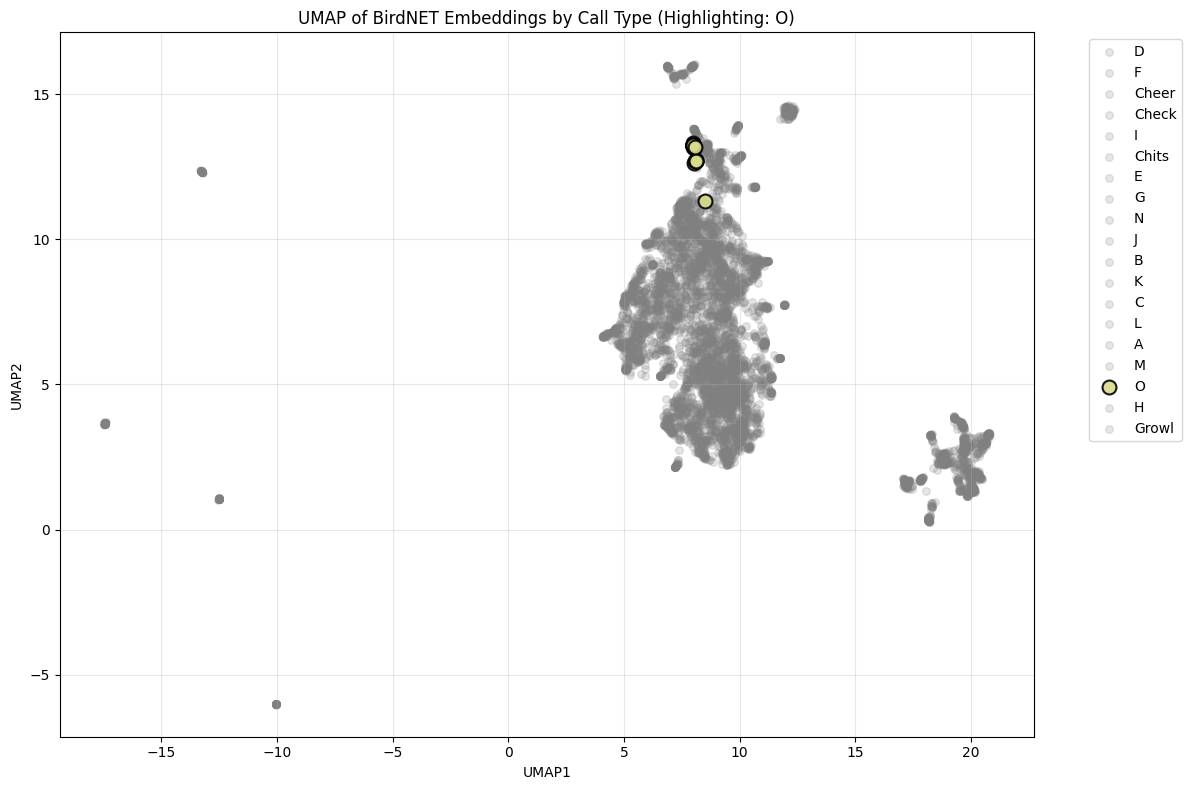


Call type distribution:
calltype
Check    3649
Cheer     707
F         256
E         248
C         202
D         201
Chits     162
B         136
K         130
G          77
I          75
M          56
J          39
L          26
O          24
N          20
A          20
H          14
Growl       5
Name: count, dtype: int64


In [35]:
# Plot UMAP results
# Set this to highlight a specific call type (e.g., 'Check', 'Cheer', etc.) or None to show all equally
highlight_calltype = "O"  # Change this to the call type you want to highlight

plt.figure(figsize=(12, 8))
unique_calltypes = umap_df['calltype'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_calltypes)))

for calltype, color in zip(unique_calltypes, colors):
    mask = umap_df['calltype'] == calltype
    
    # If highlighting a specific call type, make others faded
    if highlight_calltype is not None:
        if calltype == highlight_calltype:
            # Highlight this call type - larger, brighter, on top
            plt.scatter(umap_df.loc[mask, 'UMAP1'], 
                        umap_df.loc[mask, 'UMAP2'],
                        label=calltype, 
                        alpha=0.9, 
                        s=100,
                        color=color,
                        edgecolors='black',
                        linewidths=1.5,
                        zorder=10)
        else:
            # Fade other call types
            plt.scatter(umap_df.loc[mask, 'UMAP1'], 
                        umap_df.loc[mask, 'UMAP2'],
                        label=calltype, 
                        alpha=0.2, 
                        s=30,
                        color='gray',
                        zorder=1)
    else:
        # Normal plotting
        plt.scatter(umap_df.loc[mask, 'UMAP1'], 
                    umap_df.loc[mask, 'UMAP2'],
                    label=calltype, 
                    alpha=0.6, 
                    s=50,
                    color=color)

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
title = f'UMAP of BirdNET Embeddings by Call Type'
if highlight_calltype:
    title += f' (Highlighting: {highlight_calltype})'
plt.title(title)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCall type distribution:")
print(umap_df['calltype'].value_counts())

t-SNE Analysis

Loaded data with shape: (6047, 1028)
Number of embedding features: 1026

Running t-SNE...
This may take a few minutes for large datasets...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6047 samples in 0.022s...
[t-SNE] Computed neighbors for 6047 samples in 0.469s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6047
[t-SNE] Computed conditional probabilities for sample 2000 / 6047
[t-SNE] Computed conditional probabilities for sample 3000 / 6047
[t-SNE] Computed conditional probabilities for sample 4000 / 6047
[t-SNE] Computed conditional probabilities for sample 5000 / 6047
[t-SNE] Computed conditional probabilities for sample 6000 / 6047
[t-SNE] Computed conditional probabilities for sample 6047 / 6047
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.110283
[t-SNE] KL divergence after 1000 iterations: 1.608429
t-SNE transformation complete!


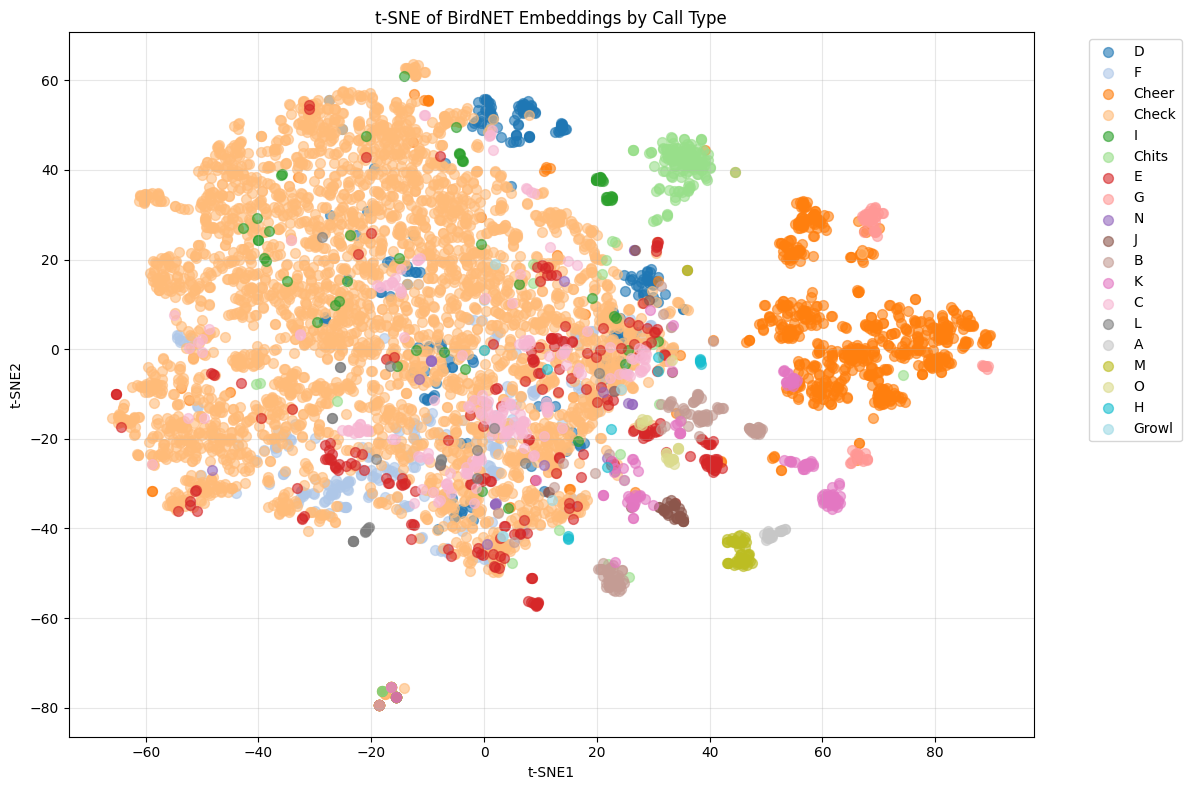


Call type distribution:
calltype
Check    3649
Cheer     707
F         256
E         248
C         202
D         201
Chits     162
B         136
K         130
G          77
I          75
M          56
J          39
L          26
O          24
N          20
A          20
H          14
Growl       5
Name: count, dtype: int64


In [ ]:
# t-SNE Analysis
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV with embeddings and calltype
csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv"
df = pd.read_csv(csv_path)

print(f"Loaded data with shape: {df.shape}")

# Separate metadata from embeddings
metadata_cols = ['calltype', 'file']
embedding_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Number of embedding features: {len(embedding_cols)}")

# Extract embeddings as numpy array
X = df[embedding_cols].values
y = df['calltype'].values

# Run t-SNE
print("\nRunning t-SNE...")
print("This may take a few minutes for large datasets...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X)

print("t-SNE transformation complete!")

# Create a DataFrame with t-SNE results
tsne_df = pd.DataFrame({
    'tSNE1': X_tsne[:, 0],
    'tSNE2': X_tsne[:, 1],
    'calltype': y
})


t-SNE plot

In [ ]:
# Plot t-SNE results
highlight_calltype = None  # Change to highlight specific call type

plt.figure(figsize=(12, 8))
unique_calltypes = tsne_df['calltype'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_calltypes)))

for calltype, color in zip(unique_calltypes, colors):
    mask = tsne_df['calltype'] == calltype
    
    # If highlighting a specific call type, make others faded
    if highlight_calltype is not None:
        if calltype == highlight_calltype:
            plt.scatter(tsne_df.loc[mask, 'tSNE1'], 
                        tsne_df.loc[mask, 'tSNE2'],
                        label=calltype, 
                        alpha=0.9, 
                        s=100,
                        color=color,
                        edgecolors='black',
                        linewidths=1.5,
                        zorder=10)
        else:
            plt.scatter(tsne_df.loc[mask, 'tSNE1'], 
                        tsne_df.loc[mask, 'tSNE2'],
                        label=calltype, 
                        alpha=0.2, 
                        s=30,
                        color='gray',
                        zorder=1)
    else:
        plt.scatter(tsne_df.loc[mask, 'tSNE1'], 
                    tsne_df.loc[mask, 'tSNE2'],
                    label=calltype, 
                    alpha=0.6, 
                    s=50,
                    color=color)

plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
title = 't-SNE of BirdNET Embeddings by Call Type'
if highlight_calltype:
    title += f' (Highlighting: {highlight_calltype})'
plt.title(title)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCall type distribution:")
print(tsne_df['calltype'].value_counts())


In [5]:
species_names = preds.columns.tolist()

In [8]:
print(species_names)
# lets find the ones that contain the name "blackbird"
blackbird_species = [name for name in species_names if "blackbird" in name.lower()]
print(blackbird_species)

['Abroscopus albogularis_Rufous-faced Warbler', 'Abroscopus schisticeps_Black-faced Warbler', 'Abroscopus superciliaris_Yellow-bellied Warbler', 'Aburria aburri_Wattled Guan', 'Acanthagenys rufogularis_Spiny-cheeked Honeyeater', 'Acanthidops bairdi_Peg-billed Finch', 'Acanthis cabaret_Lesser Redpoll', 'Acanthis flammea_Common Redpoll', 'Acanthis hornemanni_Hoary Redpoll', 'Acanthisitta chloris_Rifleman', 'Acanthiza apicalis_Inland Thornbill', 'Acanthiza chrysorrhoa_Yellow-rumped Thornbill', 'Acanthiza ewingii_Tasmanian Thornbill', 'Acanthiza inornata_Western Thornbill', 'Acanthiza lineata_Striated Thornbill', 'Acanthiza nana_Yellow Thornbill', 'Acanthiza pusilla_Brown Thornbill', 'Acanthiza reguloides_Buff-rumped Thornbill', 'Acanthiza uropygialis_Chestnut-rumped Thornbill', 'Acanthorhynchus superciliosus_Western Spinebill', 'Acanthorhynchus tenuirostris_Eastern Spinebill', 'Accipiter badius_Gebande Sperwer', 'Accipiter bicolor_Bicolored Hawk', 'Accipiter cirrocephalus_Collared Sparrow